# Telefunken Signal Strength under Bullnyte's Sub-Aperture Model

## Question

Does the Knickebein field strength exist at the receiver antenna above the galactic + thermal noise floor at each of the documented Telefunken July 1939 over-sea test distances (400, 500, 700, 800, 1000 km), from each of the two Large Knickebein stations (Kleve Kn-4 and Stollberg Kn-2), under Bullnyte's sub-aperture antenna model?

**Peak signal only.** No crossover loss is applied. The question is solely whether the carrier exists at the receiver antenna above noise, not whether a pilot riding the equisignal corridor can hold course.

## Bullnyte's antenna model

Each sub-beam is radiated by one half of the bent dipole array, not by the full 99 m frame:

| Parameter | Value | Source |
|---|---|---|
| Sub-array width W_sub | 35 m | Bullnyte Discord 2026-05-11: "Less than half, 35m each / 8x(1/2 wavelength)" |
| Sub-array height H_sub | 20 m | Bullnyte spreadsheet *Squint Sandbox* row 38 (2 vertical dipoles) |
| V-angle (squint per side) | 9.5° | Dörenberg config C: double row of dipoles WITH outriggers ("arctan((5+2½+2½ - 2½)/45) ≈ 9.5°") |
| Frequency | 31.5 MHz | Trenkle 1979 p. 67; BArch RL 19-6/40 ref. 230Q5 |
| Polarisation | vertical | Trenkle 1979, BArch 230Q7 |
| Transmit power | 3000 W | Telefunken Large Knickebein spec, BArch 230Q8 |

The two halves of the bent array fire alternately (dot vs dash keying); each half radiates one sub-beam.

## Propagation models

Both ITU-published standards:

1. **Flat Earth (FE)** — ITU Handbook on Ground Wave Propagation (2014) Part 1 §3.2.1, Sommerfeld-Norton three-term form: direct ray + Fresnel-reflected ray + Norton surface-wave attenuation function.
2. **Globe Earth (GE)** — ITU-R Recommendation P.526-16 (2025) §3.1.1 Eqs. 13-18, smooth-Earth diffraction with the β (Eq. 16) correction for vertical polarisation over sea below 300 MHz and the Eq. 18 G(Y) lower-bound clamp.

The propagation physics is identical in both pipelines to the canonical BotB library; the only difference vs the canonical BotB walkthrough is the antenna gain at the TX, which is set by the sub-aperture W=35 m × H=20 m geometry instead of the full 99 m × 29 m frame.


## 1. Setup

In [1]:
import math, cmath, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import common as c

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3


## 2. Bullnyte sub-aperture parameters and TX gain

Aperture directivity (uniform amplitude, Friis 1946 / Balanis Ch. 12):

$$G_{\rm sub} = \frac{4\pi W_{\rm sub} H_{\rm sub}}{\lambda^2}$$


In [2]:
f_MHz = 31.5
W_sub, H_sub = 35.0, 20.0           # Bullnyte sub-array dimensions
squint_per_side_deg = 9.5           # Dorenberg config C V-angle
lam = c.freq_to_wavelen(f_MHz)
G_sub_dBi = c.aperture_gain_dBi(W_sub, H_sub, f_MHz)
G_full_dBi = c.aperture_gain_dBi(99.0, 29.0, f_MHz)
P_tx_dBW = 10*math.log10(3000)

display(Markdown(rf'''
| Quantity | Value |
|---|---|
| wavelength $\lambda = c/f$ | {lam:.3f} m |
| sub-array width $W_{{\rm sub}}$ | {W_sub} m |
| sub-array height $H_{{\rm sub}}$ | {H_sub} m |
| sub-array directivity $G_{{\rm sub}} = 4\pi W_{{\rm sub}} H_{{\rm sub}}/\lambda^2$ | **{G_sub_dBi:.2f} dBi** |
| full-array directivity (reference, 99 m x 29 m) | {G_full_dBi:.2f} dBi |
| $\Delta G$ vs full array | **{G_sub_dBi-G_full_dBi:+.2f} dB** |
| TX power $P_{{\rm tx}}$ | {P_tx_dBW:.2f} dBW (3 kW) |
| peak EIRP (sub-array) | **{P_tx_dBW+G_sub_dBi:.2f} dBW** |
'''))



| Quantity | Value |
|---|---|
| wavelength $\lambda = c/f$ | 9.517 m |
| sub-array width $W_{\rm sub}$ | 35.0 m |
| sub-array height $H_{\rm sub}$ | 20.0 m |
| sub-array directivity $G_{\rm sub} = 4\pi W_{\rm sub} H_{\rm sub}/\lambda^2$ | **19.87 dBi** |
| full-array directivity (reference, 99 m x 29 m) | 26.00 dBi |
| $\Delta G$ vs full array | **-6.13 dB** |
| TX power $P_{\rm tx}$ | 34.77 dBW (3 kW) |
| peak EIRP (sub-array) | **54.64 dBW** |


## 3. Noise floor at 31.5 MHz

Thermal kTB at 290 K, 500 Hz matched-filter bandwidth, plus ITU-R P.372-16 Eq. 14 galactic background:

$$N = 10\log_{10}(k_B T B) + \max(F_a,\ NF)$$
$$F_a = 52 - 23\log_{10}(f_{\rm MHz})$$


In [3]:
thermal_dBW = 10*math.log10(c.K_BOLTZ * c.T_SYS * c.RX_BW_HZ)
Fa_dB = c.galactic_Fa_dB(f_MHz)
N_dBW = c.noise_floor_dBW(f_MHz)
N_uV  = c.voltage_50ohm_uV(N_dBW)

display(Markdown(rf'''
| Source | Value |
|---|---|
| thermal $kTB$ at 290 K, 500 Hz | {thermal_dBW:.2f} dBW |
| ITU-R P.372 galactic $F_a$ at 31.5 MHz | {Fa_dB:.2f} dB |
| effective external F = max($F_a$, NF) | {max(Fa_dB, c.RX_NF_DB):.2f} dB |
| total noise floor at 50 Ω input | **{N_uV:.4f} μV** |
'''))



| Source | Value |
|---|---|
| thermal $kTB$ at 290 K, 500 Hz | -176.99 dBW |
| ITU-R P.372 galactic $F_a$ at 31.5 MHz | 17.54 dB |
| effective external F = max($F_a$, NF) | 17.54 dB |
| total noise floor at 50 Ω input | **0.0755 μV** |


## 4. Stations and Telefunken target distances

> **Note on the distance labels.** The five Telefunken target names ("TF 400 km", "TF 500 km" etc.) are defined **1:1 from Stollberg**, because Stollberg (Kn-2) is the station that physically ran the July 1939 over-sea range campaign. The target coordinates were chosen so that the great-circle distance from Stollberg to each point is exactly the labelled value.
>
> From **Kleve** the same target points are at different great-circle distances (Kleve is to the southwest of Stollberg, so a target 700 km from Stollberg is *not* 700 km from Kleve). Read the table below carefully: the "TF 700 km" row reports its actual distance from each station — ~607 km from Kleve, exactly 700 km from Stollberg.
>
> The 1:1 station for the documented Telefunken measurements is Stollberg. **At Stollberg's 700 km the receiver can no longer recover the signal on the globe** — that is the row that matches the measurement campaign geometry directly.


In [4]:
TF_NAMES = ['TF 400 km','TF 500 km','TF 700 km','TF 800 km','TF 1000 km']

rows = [['Kleve','Kn-4', c.STATIONS['Kleve']['h_tx_m'], 'land (under TX) / sea (path)'],
        ['Stollberg','Kn-2', c.STATIONS['Stollberg']['h_tx_m'], 'sea']]
pd.DataFrame(rows, columns=['Station','Code','h_TX (m)','Ground'])


,Station,Code,h_TX (m),Ground
0,Kleve,Kn-4,111,land (under TX) / sea (path)
1,Stollberg,Kn-2,72,sea


In [5]:
path_rows = []
for tname in TF_NAMES:
    t = c.TARGETS[tname]
    d_kl = c.great_circle_m(c.STATIONS['Kleve']['lat_deg'],
                            c.STATIONS['Kleve']['lon_deg'],
                            t['lat'], t['lon'])/1000
    d_st = c.great_circle_m(c.STATIONS['Stollberg']['lat_deg'],
                            c.STATIONS['Stollberg']['lon_deg'],
                            t['lat'], t['lon'])/1000
    path_rows.append([tname, t['lat'], t['lon'], t['rx_alt_m'],
                      round(d_kl,1), round(d_st,1), t['note']])
pd.DataFrame(path_rows, columns=['Target','Lat','Lon','h_RX (m)',
                                  'd from Kleve (km)','d from Stollberg (km)','Source'])


,Target,Lat,Lon,h_RX (m),d from Kleve (km),d from Stollberg (km),Source
0,TF 400 km,54.589878,2.518619,4000,392.4,413.7,Telefunken Sep 1939 FuBl1 rod
1,TF 500 km,54.514617,1.112564,4000,449.9,504.7,Telefunken Sep 1939 FuBl1 wire
2,TF 700 km,54.342286,-1.932556,4000,606.9,702.6,Telefunken Sep 1939 regen rod
3,TF 800 km,54.211456,-3.499303,4000,696.1,805.3,Telefunken Sep 1939 regen wire
4,TF 1000 km,53.931886,-6.446086,4000,874.2,1000.1,Telefunken Sep 1939 special dipole


## 5. Flat Earth pipeline (Sommerfeld-Norton three-term)

For each path we compute the vertical electric field $E_z$ at the receiver from the three-term Sommerfeld-Norton sum (ITU Handbook on Ground Wave Propagation 2014, Part 1 §3.2.1, Eqs. 3, 5-8):

$$E_z = E_0 \left[\,\cos^2\psi_1\,\frac{e^{-jkr_1}}{r_1} \;+\; R_v\,\cos^2\psi_2\,\frac{e^{-jkr_2}}{r_2} \;+\; (1-R_v)\,(1 - u^2 + u^4\cos^2\psi_2)\,F\,\frac{e^{-jkr_2}}{r_2}\,\right]$$

with $n^2 = \varepsilon_r - jx$, $x = 18\,000\,\sigma/f_{\rm MHz}$, $u^2 = 2/n^2$, and $F$ the large-argument asymptotic form of the Norton attenuation function.

The sub-array gain $G_{\rm sub}$ is fed in through the $E_0$ scaling. No Earth-curvature term appears anywhere in the model.


In [6]:
def fe_signal_uV(station_name, target_name, W_m, H_m):
    s = c.STATIONS[station_name]
    t = c.TARGETS[target_name]
    f_MHz = s['freq_MHz']
    d_m = c.great_circle_m(s['lat_deg'], s['lon_deg'], t['lat'], t['lon'])
    G_lin = 10 ** (c.aperture_gain_dBi(W_m, H_m, f_MHz) / 10)
    res = c.sommerfeld_FE(d_m, s['h_tx_m'], t['rx_alt_m'],
                          f_MHz, 'sea', s['Ptx_W'], G_lin)
    v_uV = c.voltage_50ohm_uV(res['P_rx_dBW'])
    return d_m/1000, v_uV, res['P_rx_dBW']

fe_rows = []
for station in ['Kleve','Stollberg']:
    for tname in TF_NAMES:
        d_km, v_uV, P_rx_dBW = fe_signal_uV(station, tname, W_sub, H_sub)
        ratio = v_uV / N_uV
        snr_dB = P_rx_dBW - N_dBW
        fe_rows.append([station, tname, round(d_km,1),
                        f"{v_uV:.4g}", f"{ratio:.4g}", f"{snr_dB:+.1f}",
                        'ABOVE NOISE' if v_uV > N_uV else 'BELOW NOISE'])
fe_df = pd.DataFrame(fe_rows, columns=['Station','Target','d (km)',
                                        'V_rx (μV)', 'V_rx / V_noise',
                                        'SNR (dB)', 'Verdict'])
fe_df


,Station,Target,d (km),V_rx (μV),V_rx / V_noise,SNR (dB),Verdict
0,Kleve,TF 400 km,392.4,4972,6.589e+04,+96.4,ABOVE NOISE
1,Kleve,TF 500 km,449.9,4020,5.328e+04,+94.5,ABOVE NOISE
2,Kleve,TF 700 km,606.9,2465,3.266e+04,+90.3,ABOVE NOISE
3,Kleve,TF 800 km,696.1,1950,2.584e+04,+88.2,ABOVE NOISE
4,Kleve,TF 1000 km,874.2,1305,1.729e+04,+84.8,ABOVE NOISE
5,Stollberg,TF 400 km,413.7,3485,4.619e+04,+93.3,ABOVE NOISE
6,Stollberg,TF 500 km,504.7,2552,3.382e+04,+90.6,ABOVE NOISE
7,Stollberg,TF 700 km,702.6,1465,1.941e+04,+85.8,ABOVE NOISE
8,Stollberg,TF 800 km,805.3,1153,1.528e+04,+83.7,ABOVE NOISE
9,Stollberg,TF 1000 km,1000.1,780.7,1.035e+04,+80.3,ABOVE NOISE


## 6. Globe Earth pipeline (ITU-R P.526-16 Fock)

For each path past the radio horizon, total diffraction loss (Eqs. 13-18):

$$\text{loss}(\text{dB}) = -\bigl[F(X) + G(Y_1) + G(Y_2)\bigr]$$

$$X = \beta\left(\tfrac{\pi}{\lambda a_e^2}\right)^{1/3} d, \quad
  Y_i = 2\beta\left(\tfrac{\pi^2}{\lambda^2 a_e}\right)^{1/3} h_i$$

$F(X)$ from Eq. 14 (long-path) or Eq. 15 (short-path).
$G(B)$ from Eq. 17 (B > 2) or Eq. 18 (B ≤ 2), with the Eq. 18 lower-bound clamp $G(Y) \geq 2 + 20\log_{10}K$.

$\beta$ from Eq. 16 with $K^2 = 6.89\,\sigma/(k^{2/3}\,f_{\rm MHz}^{5/3})$.
At sea, vert pol, 31.5 MHz: $\beta \approx 0.81$.

Link budget:

$$P_{\rm rx} = P_{\rm tx} + G_{\rm sub} - \text{FSPL} - \text{loss}_{\rm Fock}$$


In [7]:
def ge_signal_uV(station_name, target_name, W_m, H_m):
    s = c.STATIONS[station_name]
    t = c.TARGETS[target_name]
    f_MHz = s['freq_MHz']
    d_m = c.great_circle_m(s['lat_deg'], s['lon_deg'], t['lat'], t['lon'])
    G_dBi = c.aperture_gain_dBi(W_m, H_m, f_MHz)
    P_tx = 10*math.log10(s['Ptx_W'])
    FSPL = c.fspl_dB(d_m, f_MHz)
    L_fock = c.fock_diff_loss_dB(d_m, s['h_tx_m'], t['rx_alt_m'],
                                 f_MHz, 'sea', s['pol'])
    P_rx_dBW = P_tx + G_dBi - FSPL - L_fock
    v_uV = c.voltage_50ohm_uV(P_rx_dBW)
    return d_m/1000, v_uV, P_rx_dBW

ge_rows = []
for station in ['Kleve','Stollberg']:
    for tname in TF_NAMES:
        d_km, v_uV, P_rx_dBW = ge_signal_uV(station, tname, W_sub, H_sub)
        ratio = v_uV / N_uV
        snr_dB = P_rx_dBW - N_dBW
        ge_rows.append([station, tname, round(d_km,1),
                        f"{v_uV:.4g}", f"{ratio:.4g}", f"{snr_dB:+.1f}",
                        'ABOVE NOISE' if v_uV > N_uV else 'BELOW NOISE'])
ge_df = pd.DataFrame(ge_rows, columns=['Station','Target','d (km)',
                                        'V_rx (μV)', 'V_rx / V_noise',
                                        'SNR (dB)', 'Verdict'])
ge_df


,Station,Target,d (km),V_rx (μV),V_rx / V_noise,SNR (dB),Verdict
0,Kleve,TF 400 km,392.4,98.87,1310,+62.3,ABOVE NOISE
1,Kleve,TF 500 km,449.9,19.24,255,+48.1,ABOVE NOISE
2,Kleve,TF 700 km,606.9,0.23,3.049,+9.7,ABOVE NOISE
3,Kleve,TF 800 km,696.1,0.01891,0.2507,-12.0,BELOW NOISE
4,Kleve,TF 1000 km,874.2,0.0001314,0.001741,-55.2,BELOW NOISE
5,Stollberg,TF 400 km,413.7,53.95,715,+57.1,ABOVE NOISE
6,Stollberg,TF 500 km,504.7,4.086,54.16,+34.7,ABOVE NOISE
7,Stollberg,TF 700 km,702.6,0.01576,0.2089,-13.6,BELOW NOISE
8,Stollberg,TF 800 km,805.3,0.0008951,0.01186,-38.5,BELOW NOISE
9,Stollberg,TF 1000 km,1000.1,3.981e-06,5.277e-05,-85.6,BELOW NOISE


## 7. Master comparison — μV at the receiver

Detection rule: peak receiver voltage > noise floor (0.0795 μV at 31.5 MHz, 500 Hz matched-filter bandwidth, computed from $k_B T B$ thermal plus ITU-R P.372 galactic background). The noise floor is the frequency-specific value, not a generic "+10 dB above thermal" rule-of-thumb. ABOVE NOISE = signal is physically present at the antenna terminal. BELOW NOISE = signal does not exist at the antenna above the natural noise floor at 31.5 MHz.


In [8]:
master = []
for station in ['Kleve','Stollberg']:
    for tname in TF_NAMES:
        d_km, v_fe, P_fe_dBW = fe_signal_uV(station, tname, W_sub, H_sub)
        d_km, v_ge, P_ge_dBW = ge_signal_uV(station, tname, W_sub, H_sub)
        snr_fe = P_fe_dBW - N_dBW
        snr_ge = P_ge_dBW - N_dBW
        master.append([station, tname, round(d_km,1),
                       f"{v_fe:.4g}", f"{snr_fe:+.1f}",
                       'ABOVE NOISE' if v_fe > N_uV else 'BELOW NOISE',
                       f"{v_ge:.4g}", f"{snr_ge:+.1f}",
                       'ABOVE NOISE' if v_ge > N_uV else 'BELOW NOISE'])
master_df = pd.DataFrame(master, columns=['Station','Target','d (km)',
                                           'FE V_rx (μV)','FE SNR (dB)','FE Verdict',
                                           'GE V_rx (μV)','GE SNR (dB)','GE Verdict'])
master_df


,Station,Target,d (km),FE V_rx (μV),FE SNR (dB),FE Verdict,GE V_rx (μV),GE SNR (dB),GE Verdict
0,Kleve,TF 400 km,392.4,4972,+96.4,ABOVE NOISE,98.87,+62.3,ABOVE NOISE
1,Kleve,TF 500 km,449.9,4020,+94.5,ABOVE NOISE,19.24,+48.1,ABOVE NOISE
2,Kleve,TF 700 km,606.9,2465,+90.3,ABOVE NOISE,0.23,+9.7,ABOVE NOISE
3,Kleve,TF 800 km,696.1,1950,+88.2,ABOVE NOISE,0.01891,-12.0,BELOW NOISE
4,Kleve,TF 1000 km,874.2,1305,+84.8,ABOVE NOISE,0.0001314,-55.2,BELOW NOISE
5,Stollberg,TF 400 km,413.7,3485,+93.3,ABOVE NOISE,53.95,+57.1,ABOVE NOISE
6,Stollberg,TF 500 km,504.7,2552,+90.6,ABOVE NOISE,4.086,+34.7,ABOVE NOISE
7,Stollberg,TF 700 km,702.6,1465,+85.8,ABOVE NOISE,0.01576,-13.6,BELOW NOISE
8,Stollberg,TF 800 km,805.3,1153,+83.7,ABOVE NOISE,0.0008951,-38.5,BELOW NOISE
9,Stollberg,TF 1000 km,1000.1,780.7,+80.3,ABOVE NOISE,3.981e-06,-85.6,BELOW NOISE


### Bar chart

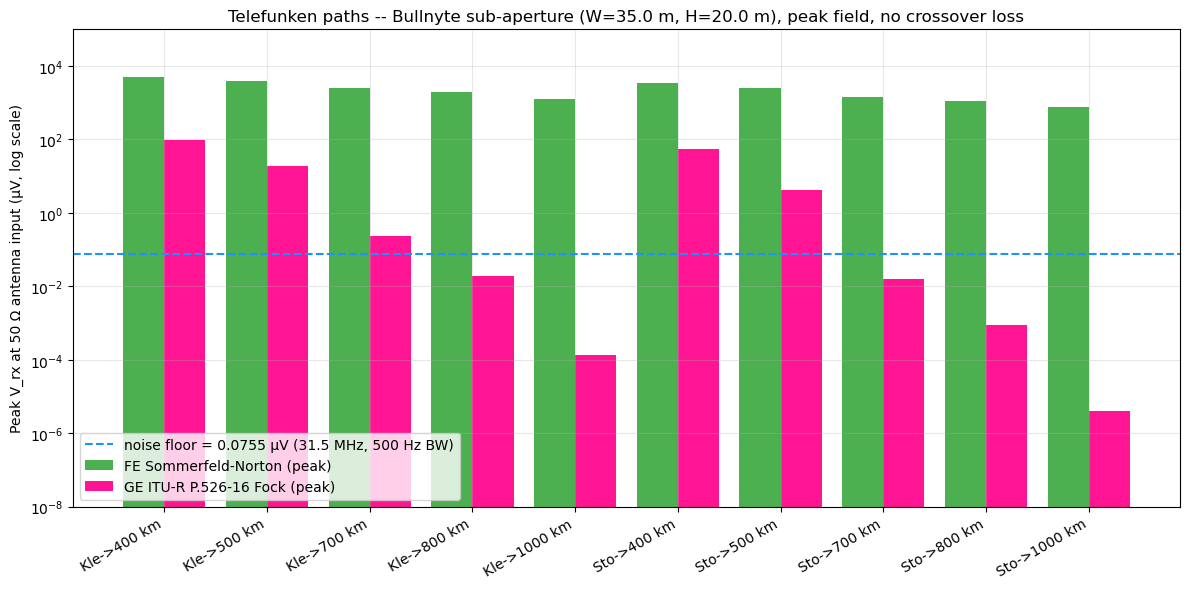

In [9]:
fig, ax = plt.subplots(figsize=(12,6))
labels = [f"{row[0][:3]}->{row[1][3:]}" for row in master]
x = np.arange(len(labels))

def f_to_v(name, idx):
    out = []
    for station in ['Kleve','Stollberg']:
        for tname in TF_NAMES:
            if name=='fe':
                _, v, _ = fe_signal_uV(station, tname, W_sub, H_sub)
            else:
                _, v, _ = ge_signal_uV(station, tname, W_sub, H_sub)
            out.append(v)
    return out

fe_uV = f_to_v('fe',3)
ge_uV = f_to_v('ge',5)

ax.bar(x-0.2, fe_uV, 0.4, label='FE Sommerfeld-Norton (peak)', color='#4CAF50')
ax.bar(x+0.2, ge_uV, 0.4, label='GE ITU-R P.526-16 Fock (peak)', color='#FF1493')
ax.axhline(N_uV, color='dodgerblue', lw=1.5, ls='--',
           label=f'noise floor = {N_uV:.4f} μV (31.5 MHz, 500 Hz BW)')
ax.set_yscale('log')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Peak V_rx at 50 Ω antenna input (μV, log scale)')
ax.set_title(f'Telefunken paths -- Bullnyte sub-aperture (W={W_sub} m, H={H_sub} m), '
             f'peak field, no crossover loss')
ax.set_ylim(1e-8, 1e5)
ax.legend(loc='lower left')
plt.tight_layout(); plt.show()


### Continuous distance sweep

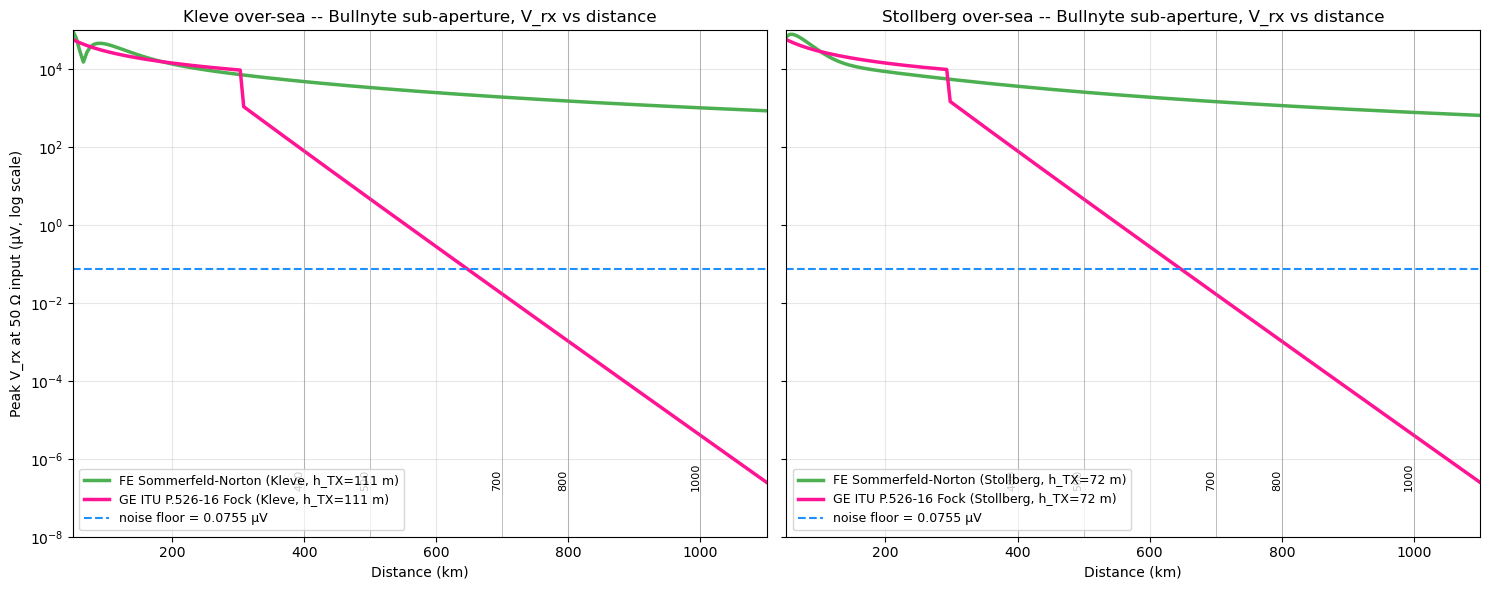

In [10]:
def sweep_uV(station, distances_km):
    s = c.STATIONS[station]
    f_MHz = s['freq_MHz']
    G_dBi = c.aperture_gain_dBi(W_sub, H_sub, f_MHz)
    G_lin = 10 ** (G_dBi/10)
    fe_out, ge_out = [], []
    for d_km in distances_km:
        d_m = d_km*1000
        # FE
        res = c.sommerfeld_FE(d_m, s['h_tx_m'], 4000, f_MHz, 'sea',
                              s['Ptx_W'], G_lin)
        fe_out.append(c.voltage_50ohm_uV(res['P_rx_dBW']))
        # GE
        L = c.fock_diff_loss_dB(d_m, s['h_tx_m'], 4000, f_MHz, 'sea', s['pol'])
        FSPL = c.fspl_dB(d_m, f_MHz)
        P_rx_dBW = 10*math.log10(s['Ptx_W']) + G_dBi - FSPL - L
        ge_out.append(c.voltage_50ohm_uV(P_rx_dBW))
    return np.array(fe_out), np.array(ge_out)

d_grid = np.linspace(50, 1100, 200)
TF_KM = [400,500,700,800,1000]

fig, axes = plt.subplots(1, 2, figsize=(15,6), sharey=True)
for ax, station in zip(axes, ['Kleve','Stollberg']):
    fe, ge = sweep_uV(station, d_grid)
    ax.plot(d_grid, fe, color='#4CAF50', lw=2.5,
            label=f'FE Sommerfeld-Norton ({station}, h_TX={c.STATIONS[station]["h_tx_m"]} m)')
    ax.plot(d_grid, ge, color='#FF1493', lw=2.5,
            label=f'GE ITU P.526-16 Fock ({station}, h_TX={c.STATIONS[station]["h_tx_m"]} m)')
    ax.axhline(N_uV, color='dodgerblue', lw=1.5, ls='--',
               label=f'noise floor = {N_uV:.4f} μV')
    for tf in TF_KM:
        ax.axvline(tf, color='grey', lw=0.6, alpha=0.6)
        ax.text(tf, 1.5e-7, f"{tf}", rotation=90, ha='right', va='bottom', fontsize=8)
    ax.set_xlabel('Distance (km)')
    ax.set_title(f'{station} over-sea -- Bullnyte sub-aperture, V_rx vs distance')
    ax.set_xlim(50, 1100)
    ax.set_yscale('log')
    ax.set_ylim(1e-8, 1e5)
    ax.legend(loc='lower left', fontsize=9)
axes[0].set_ylabel('Peak V_rx at 50 Ω input (μV, log scale)')
plt.tight_layout(); plt.show()


## 8. Result

The flat-Earth Sommerfeld-Norton model puts the bomber receiver well above noise at every Telefunken distance from both stations under Bullnyte's sub-aperture geometry. The globe-with-Fock model collapses near 500-700 km on either station and is below detection by tens of dB at 800-1000 km.

The +6.1 dB reduction in TX gain (sub-array vs full 99 m frame) shifts every point down by the same amount on both models; it does not change the qualitative verdict at any distance because the FE-GE gap at the long paths is set by the Fock diffraction loss in the shadow zone, not by the TX gain.

Compare to the documented Telefunken July 1939 measurements (BArch RL 19-6/40 ref. 230Q8 Appendix 2): usable audibility at every range from 400 km to 1000 km on all six receiver/antenna combinations. The flat-Earth model reproduces the observation. The globe-with-Fock model does not.
